Shape: (4610224, 25)
Airlines: <StringArray>
[ 'American Airlines',    'Alaska Airlines',    'JetBlue Airways',
    'Delta Air Lines',    'United Airlines', 'Southwest Airlines']
Length: 6, dtype: str
Overall on-time rate: 78.5 %


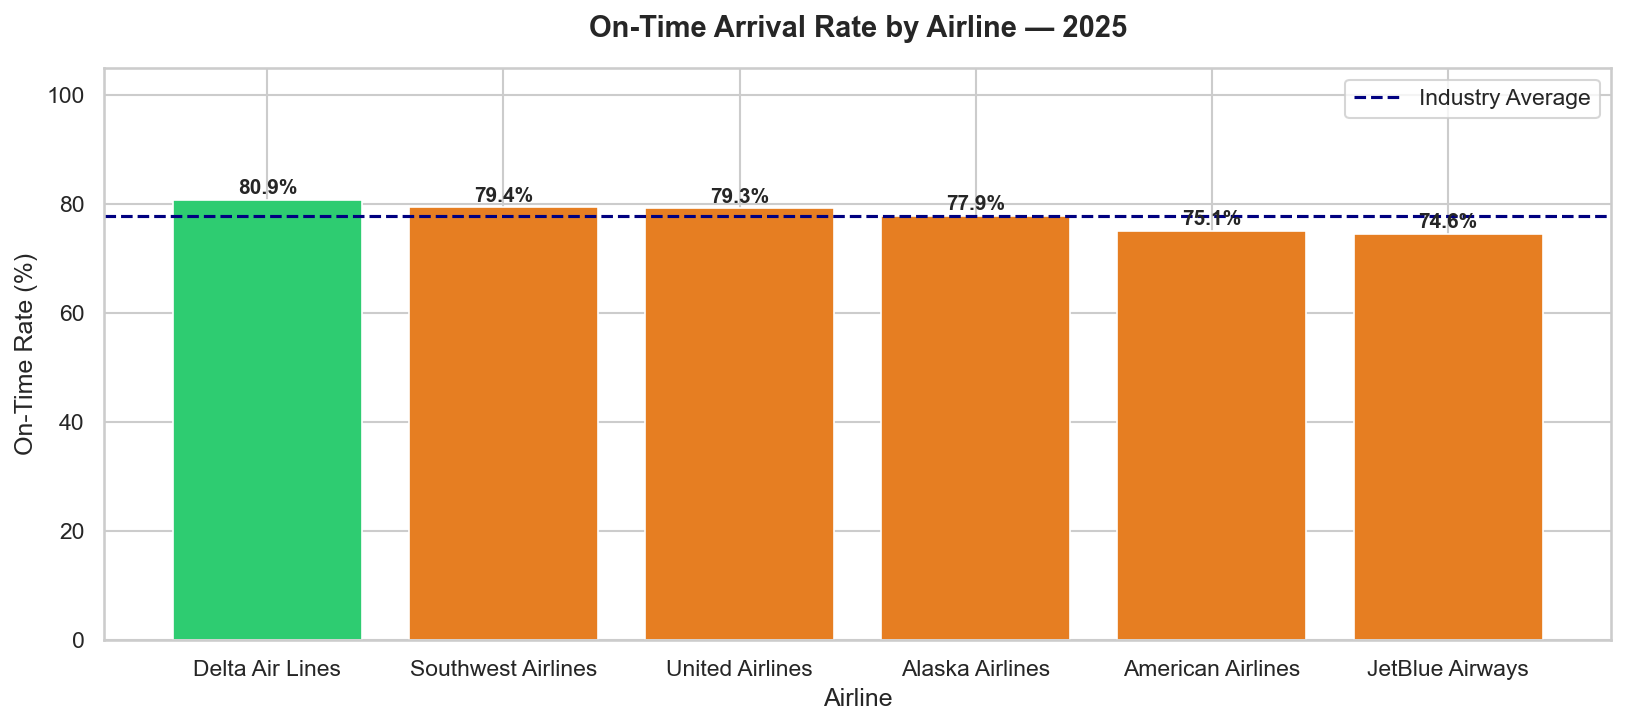

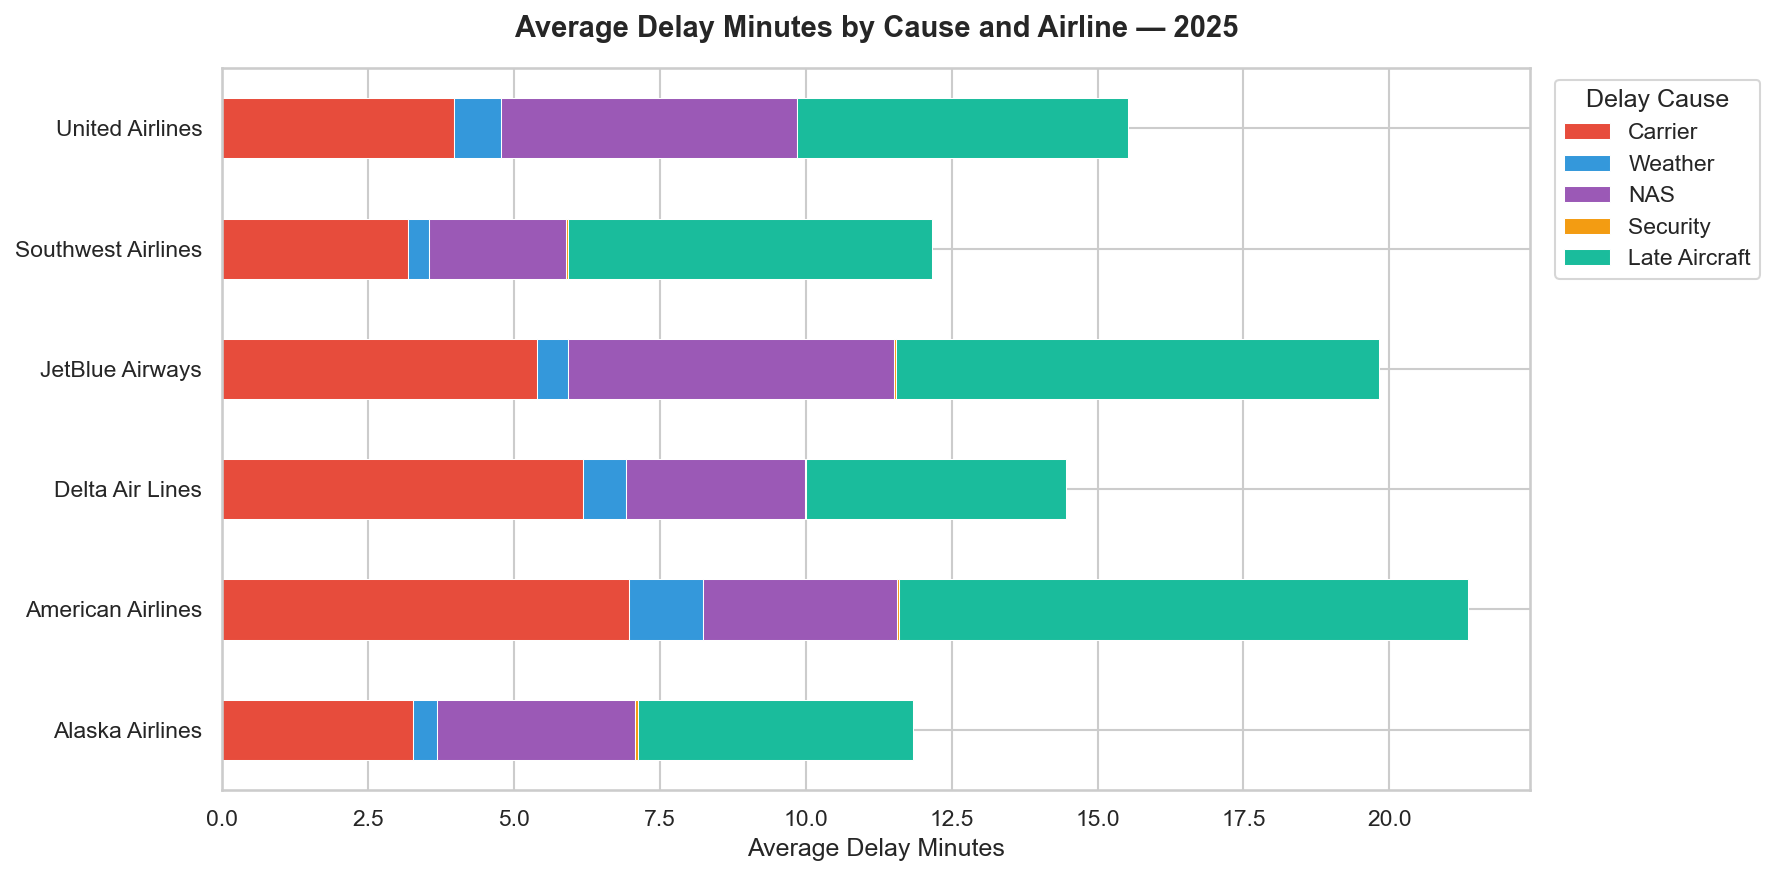

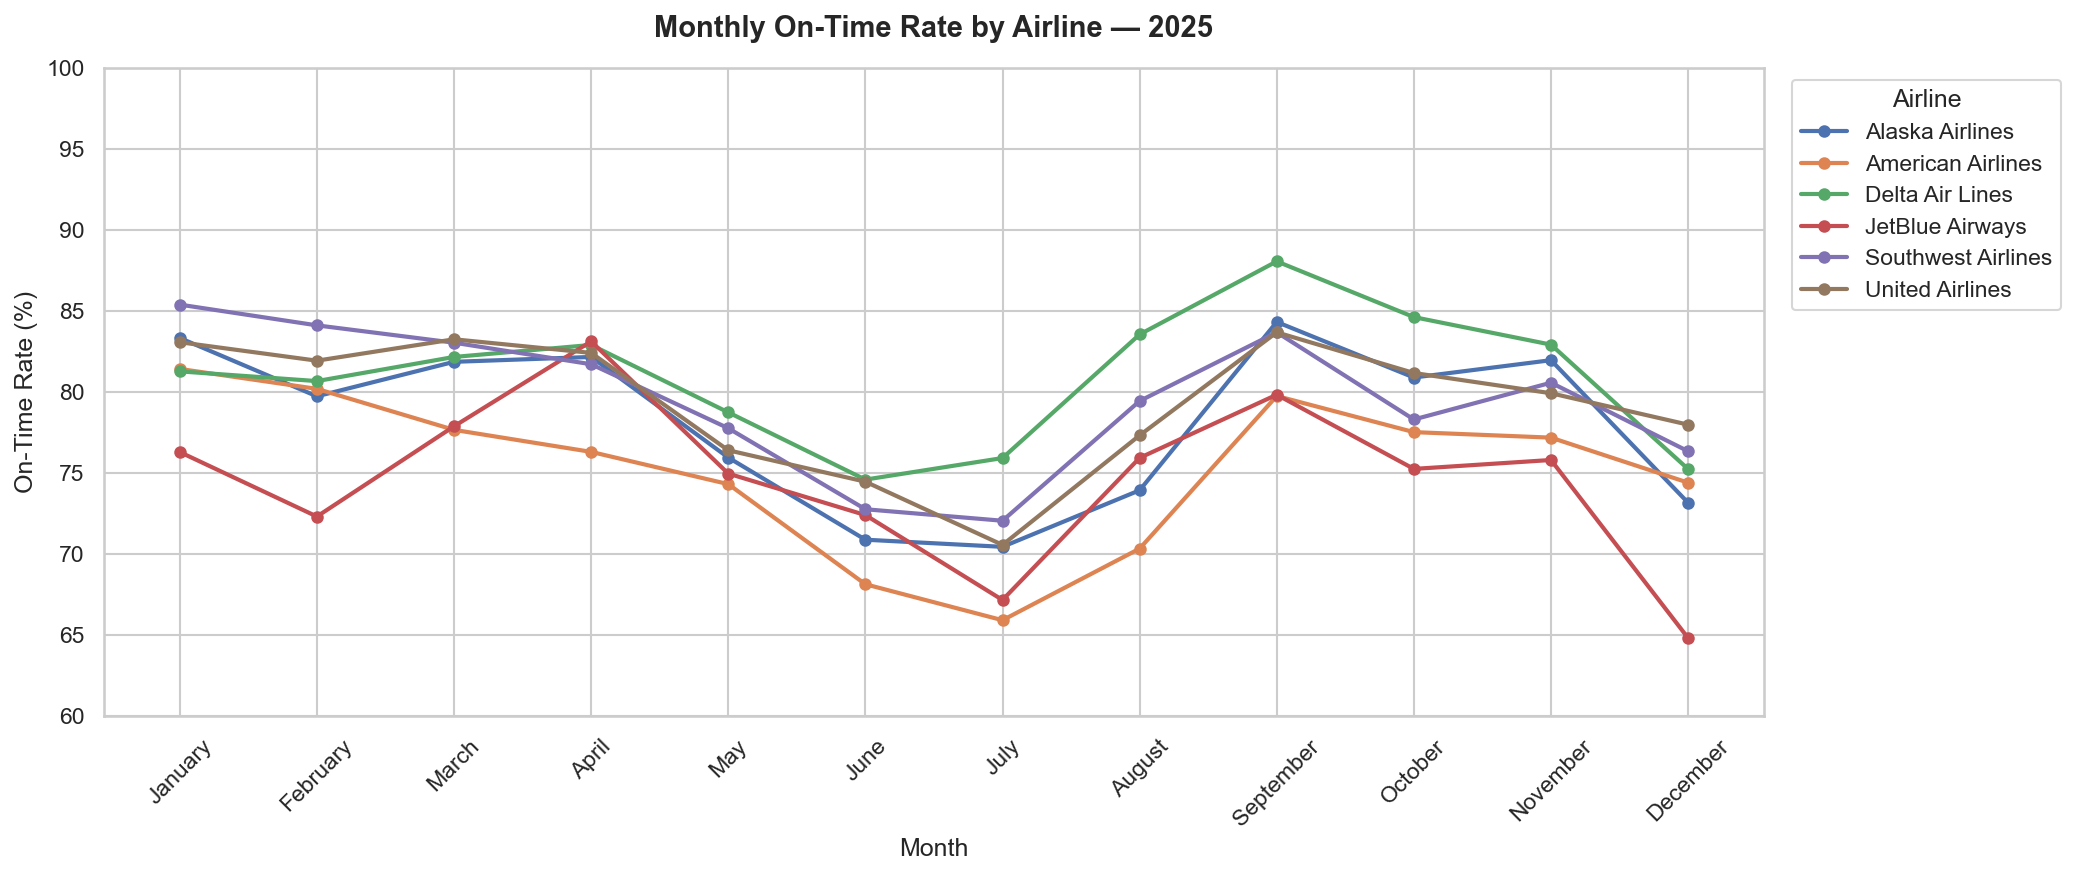

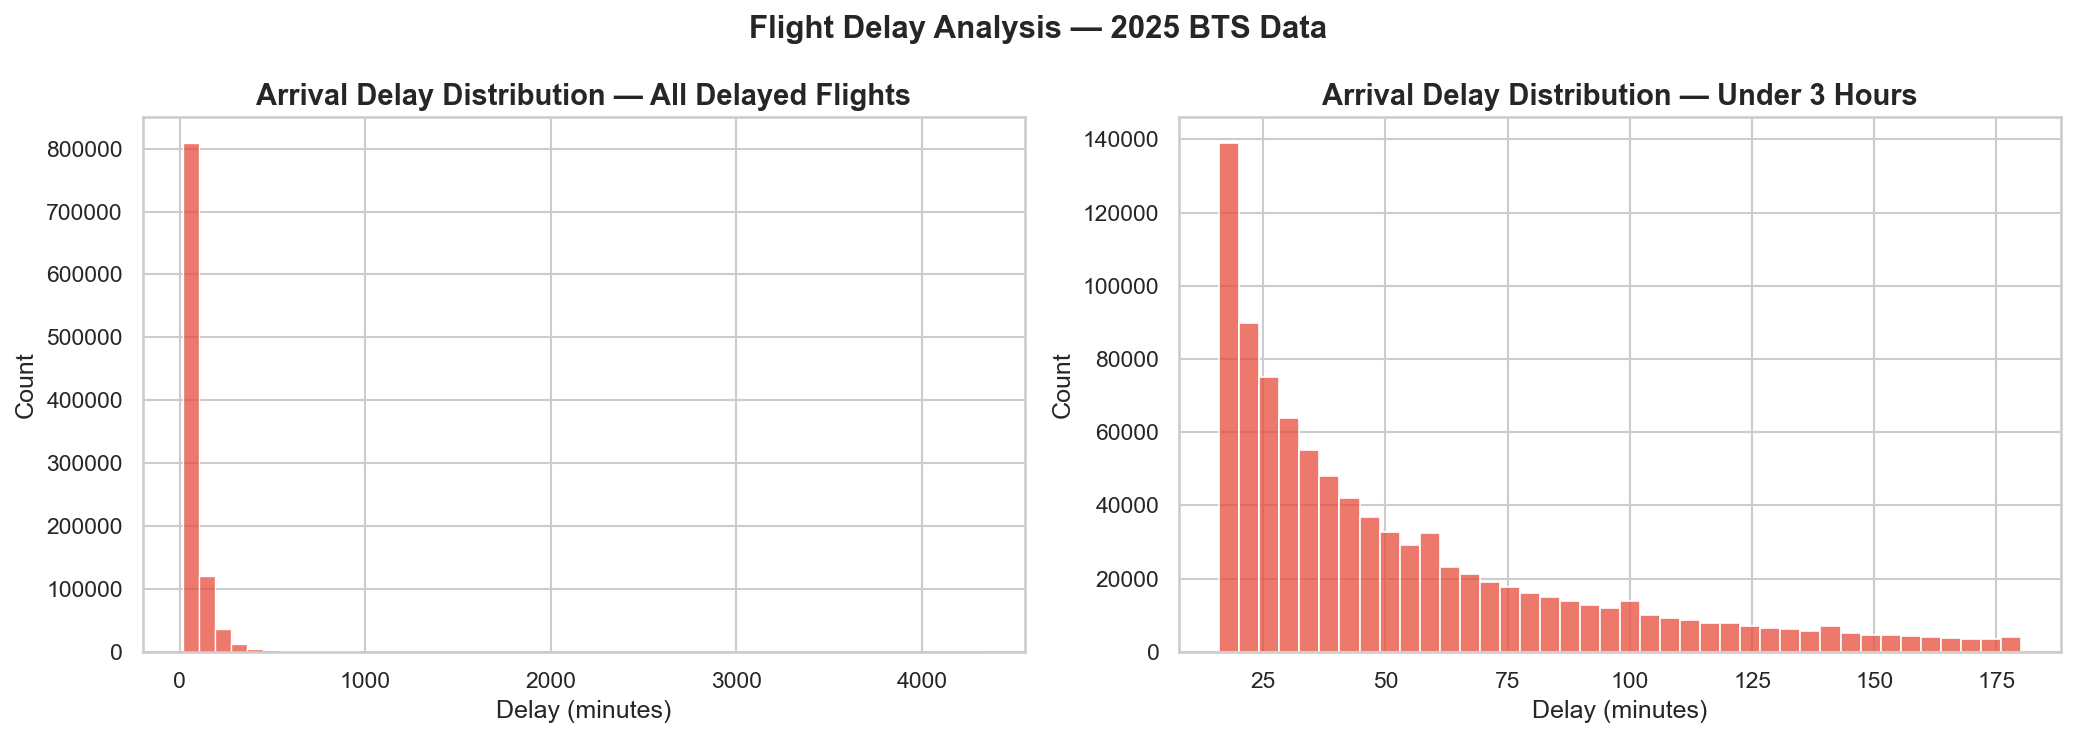

Median delay (late flights): 43.0 mins
Mean delay (late flights): 71.6 mins
Delays over 4 hours: 36323


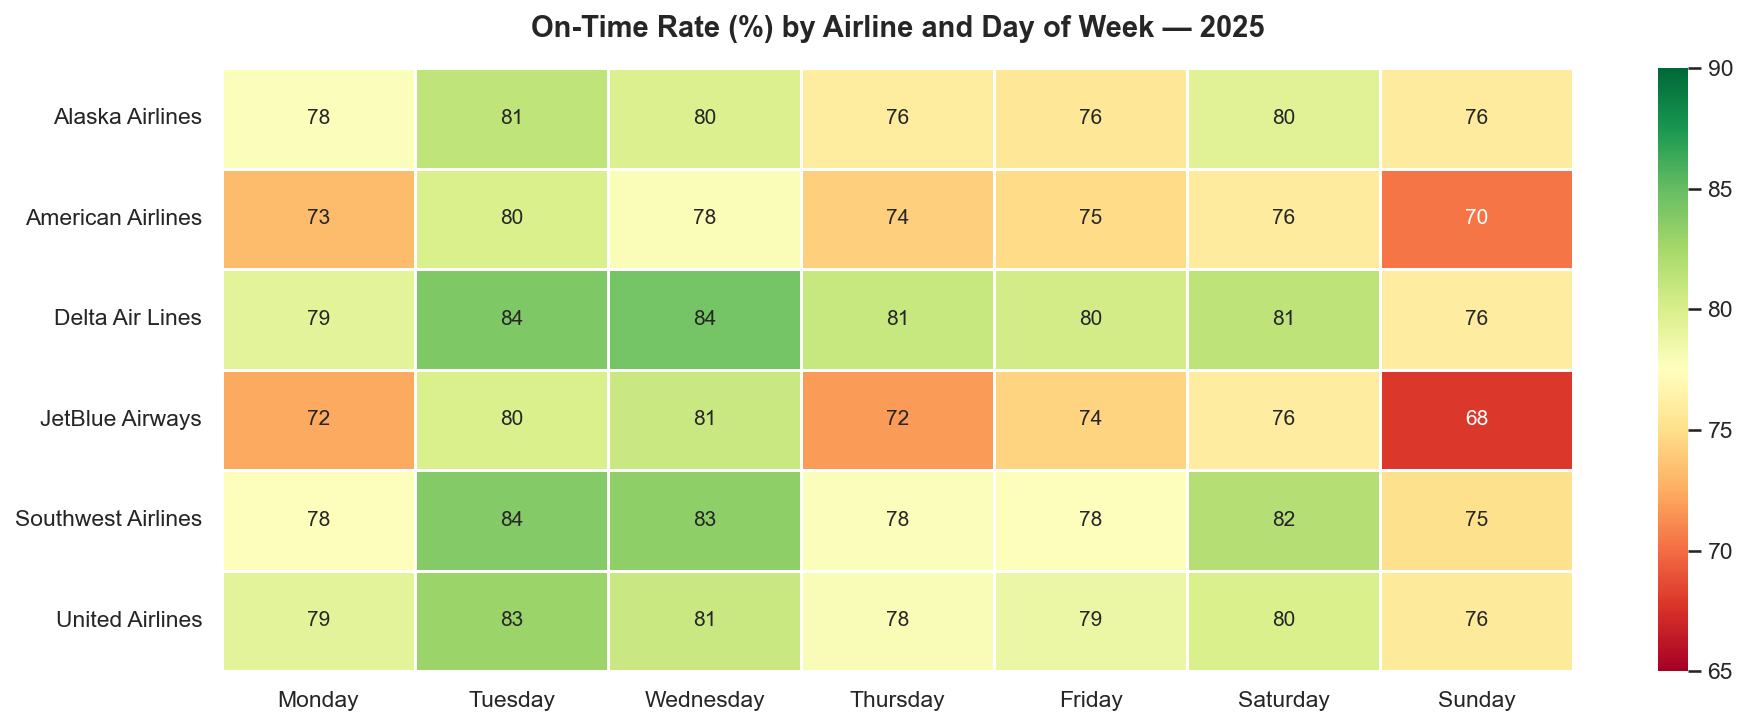

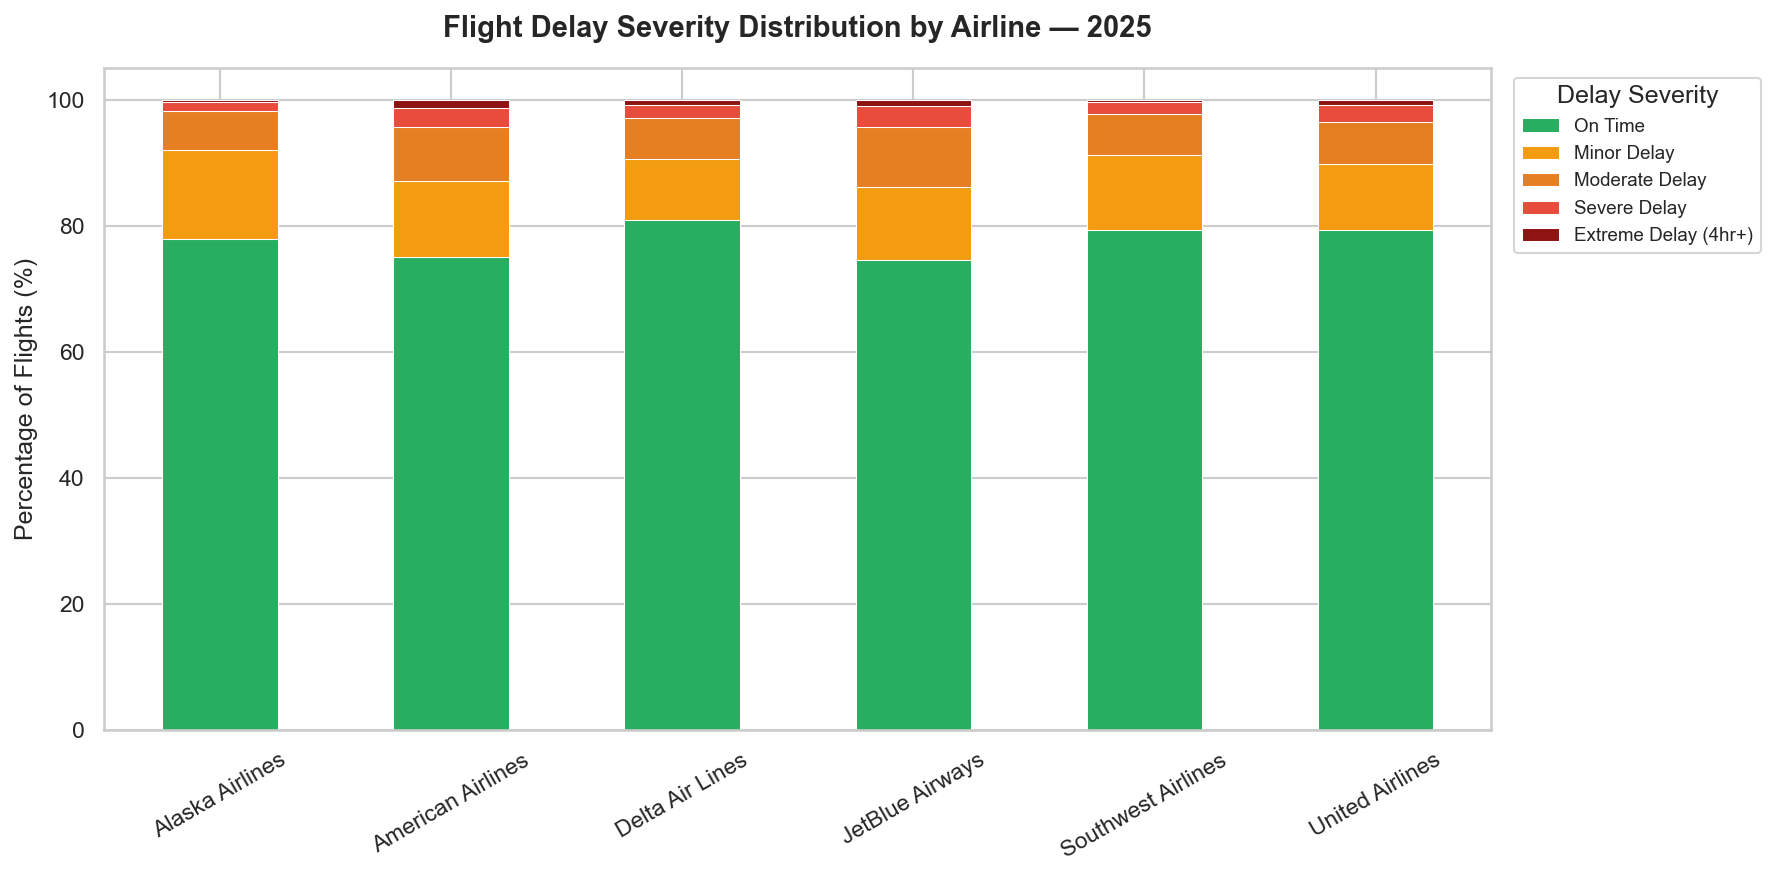

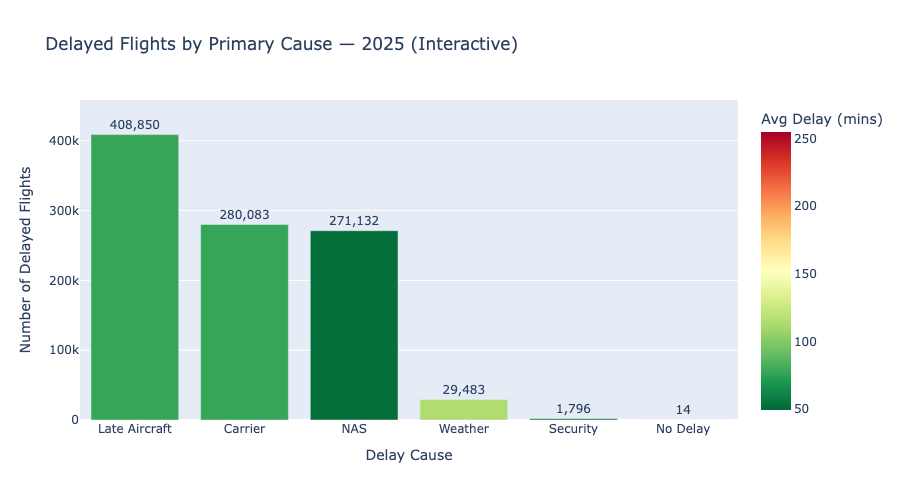

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('/Users/NilkanthPatel2/Desktop/Future/Projects/flight-delay-analysis/data/cleaned/flights_cleaned.csv', low_memory=False)

# Set global Seaborn style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']   = (12, 5)
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('Shape:', df.shape)
print('Airlines:', df['airline_name'].unique())
print('Overall on-time rate:', round(df['on_time'].mean()*100,2),'%')


# Chart 1 — On-Time Rate by Airline
airline_perf = (
    df.groupby('airline_name')['on_time']
    .mean().mul(100).round(2)
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ECC71' if v >= 80 else '#E67E22' if v >= 70 else '#E74C3C'
          for v in airline_perf['on_time']]
bars = ax.bar(airline_perf['airline_name'], airline_perf['on_time'],
              color=colors, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(airline_perf['on_time'].mean(), color='navy',
           linestyle='--', linewidth=1.5, label='Industry Average')
ax.set_title('On-Time Arrival Rate by Airline — 2025', pad=15)
ax.set_xlabel('Airline')
ax.set_ylabel('On-Time Rate (%)')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/01_on_time_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 2 — Delay Causes Breakdown
cause_cols   = ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
cause_labels = ['Carrier','Weather','NAS','Security','Late Aircraft']
cause_colors = ['#E74C3C','#3498DB','#9B59B6','#F39C12','#1ABC9C']

delay_by_airline = df.groupby('airline_name')[cause_cols].mean().round(2)
delay_by_airline.columns = cause_labels

fig, ax = plt.subplots(figsize=(12, 6))
delay_by_airline.plot(kind='barh', stacked=True, ax=ax,
                      color=cause_colors, edgecolor='white', linewidth=0.5)
ax.set_title('Average Delay Minutes by Cause and Airline — 2025', pad=15)
ax.set_xlabel('Average Delay Minutes')
ax.set_ylabel('')
ax.legend(title='Delay Cause', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visuals/02_delay_causes_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 3 — Monthly On-Time Rate Trend
monthly = (
    df.groupby(['month','month_name','airline_name'])['on_time']
    .mean().mul(100).round(2).reset_index()
)

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly['month_name'] = pd.Categorical(monthly['month_name'],
                                        categories=month_order, ordered=True)
monthly = monthly.sort_values('month')

fig, ax = plt.subplots(figsize=(14, 6))
for airline in monthly['airline_name'].unique():
    data = monthly[monthly['airline_name']==airline]
    ax.plot(data['month_name'], data['on_time'], marker='o',
            linewidth=2, markersize=5, label=airline)

ax.set_title('Monthly On-Time Rate by Airline — 2025', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('On-Time Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Airline', bbox_to_anchor=(1.01,1), loc='upper left')
ax.set_ylim(60, 100)
plt.tight_layout()
plt.savefig('../visuals/03_monthly_trend_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 4 — Delay Distribution Histogram
late_flights = df[(df['on_time']==False) & (df['ARR_DELAY']>0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(late_flights['ARR_DELAY'], bins=50,
             color='#E74C3C', edgecolor='white', ax=axes[0])
axes[0].set_title('Arrival Delay Distribution — All Delayed Flights')
axes[0].set_xlabel('Delay (minutes)')

sns.histplot(late_flights[late_flights['ARR_DELAY']<=180]['ARR_DELAY'],
             bins=40, color='#E74C3C', edgecolor='white', ax=axes[1])
axes[1].set_title('Arrival Delay Distribution — Under 3 Hours')
axes[1].set_xlabel('Delay (minutes)')

plt.suptitle('Flight Delay Analysis — 2025 BTS Data', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/04_delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median delay (late flights):', late_flights['ARR_DELAY'].median().round(1), 'mins')
print('Mean delay (late flights):',   late_flights['ARR_DELAY'].mean().round(1),   'mins')
print('Delays over 4 hours:',         (late_flights['ARR_DELAY']>240).sum())


# Chart 5 — Heatmap: Airline x Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = df.pivot_table(
    values='on_time',
    index='airline_name',
    columns='day_of_week',
    aggfunc='mean'
).mul(100).round(1)[day_order]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, vmin=65, vmax=90, ax=ax,
            annot_kws={'size':10})
ax.set_title('On-Time Rate (%) by Airline and Day of Week — 2025', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visuals/05_heatmap_airline_day.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 6 — Delay Severity by Airline
severity_order  = ['On Time','Minor Delay','Moderate Delay','Severe Delay','Extreme Delay (4hr+)']
severity_colors = ['#27AE60','#F39C12','#E67E22','#E74C3C','#8E1414']

sev = (
    df.groupby(['airline_name','delay_severity'])
    .size().reset_index(name='count')
)
sev_pct = sev.copy()
sev_pct['pct'] = sev_pct.groupby('airline_name')['count'].transform(lambda x: x/x.sum()*100)

pivot_sev = sev_pct.pivot(index='airline_name', columns='delay_severity', values='pct')
pivot_sev = pivot_sev[[c for c in severity_order if c in pivot_sev.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
pivot_sev.plot(kind='bar', stacked=True, ax=ax,
               color=severity_colors[:len(pivot_sev.columns)],
               edgecolor='white', linewidth=0.5)
ax.set_title('Flight Delay Severity Distribution by Airline — 2025', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Percentage of Flights (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Delay Severity', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../visuals/06_delay_severity_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()


# Chart 7 — Interactive Delay Cause Chart
worst_routes = (
    df[df['on_time']==False]
    .groupby('primary_delay_cause')
    .agg(
        delayed_flights=('primary_delay_cause','count'),
        avg_delay=('ARR_DELAY','mean')
    ).round(2).reset_index()
    .sort_values('delayed_flights', ascending=False)
)

fig = px.bar(
    worst_routes,
    x='primary_delay_cause',
    y='delayed_flights',
    color='avg_delay',
    color_continuous_scale='RdYlGn_r',
    text='delayed_flights',
    title='Delayed Flights by Primary Cause — 2025 (Interactive)',
    labels={
        'primary_delay_cause': 'Delay Cause',
        'delayed_flights':     'Number of Delayed Flights',
        'avg_delay':           'Avg Delay (mins)'
    }
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(height=500, showlegend=False)
fig.write_html('../visuals/07_delay_causes_interactive.html')
fig.show()